In [9]:
# ── Setup ──────────────────────────────────────────────────────────────────────
# Toy simulation of a social-grouping system:
#   1) Users are repeatedly shuffled into groups-of-5 (within-month steps).
#   2) Inside each group every user ranks the other 4 → directed edges in G.
#   3) After all steps, we form ~10-person "monthly groupchats" using
#      neighbor-structure compatibility (Resource Allocation index).
#   4) Export interaction graph + overlay to .gexf for Gephi.

import random, time
from itertools import combinations
from typing import Dict, List, Optional, Set, Tuple

import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import clear_output

# --- Knobs ---
SEED            = 7
GROUP_SIZE      = 5      # within-step group size
INITIAL_USERS   = 25
NEW_PER_STEP    = (7, 15)  # how many new users each step (inclusive)
N_STEPS         = 8

# --- State ---
rng = random.Random(SEED)
G   = nx.DiGraph()                                 # interaction graph
G.add_nodes_from(range(1, INITIAL_USERS + 1))
for u in G.nodes:
    G.nodes[u]["activity"] = {}                    # step -> activity score
paired_before: Set[Tuple[int, int]] = set()        # undirected pairs ever co-grouped
pos: Optional[Dict[int, Tuple[float, float]]] = None  # cached layout


step=8  new=9  groups=22  users=114  edges=2342


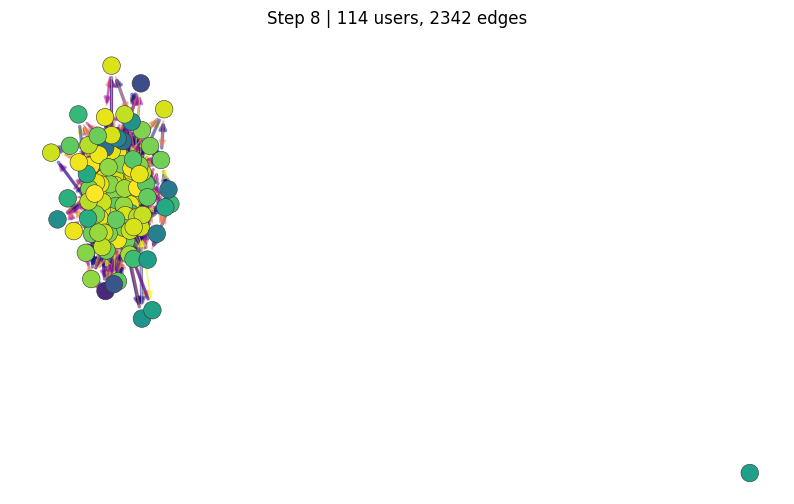

In [10]:
# ── Simulation (within-month) ──────────────────────────────────────────────────
# Each step: add new users → form groups of 5 → rank within groups → draw.

def form_groups(users, paired_before, rng):
    """Greedy grouping into GROUP_SIZE, minimizing repeated pairs."""
    users = users[:]
    rng.shuffle(users)
    groups, leftovers = [], []
    while len(users) >= GROUP_SIZE:
        grp = [users.pop(0)]
        while len(grp) < GROUP_SIZE:
            best_i, best_pen = 0, None
            for i, c in enumerate(users):
                pen = sum(tuple(sorted([c, m])) in paired_before for m in grp)
                if best_pen is None or pen < best_pen:
                    best_i, best_pen = i, pen
                    if pen == 0:
                        break
            grp.append(users.pop(best_i)) 
        groups.append(grp)
        for a, b in combinations(grp, 2):
            paired_before.add(tuple(sorted([a, b])))
    return groups, users


def add_edges(G, groups, step, rng):
    """Each user ranks group-mates 1..4 → directed edges with full encounter history."""
    for grp in groups:
        for u in grp:
            others = [v for v in grp if v != u]
            rng.shuffle(others)
            activity_u = G.nodes[u]["activity"][step]
            for rank, v in enumerate(others, 1):
                if not G.has_edge(u, v):
                    G.add_edge(u, v, n=0, encounters=[])
                e = G[u][v]
                e["rank"]  = rank       # latest rank (quick access)
                e["step"]  = step       # latest step (quick access)
                e["n"]    += 1
                e["encounters"].append((step, rank, activity_u))


def draw(G, pos, step):
    """Simple per-step visualization."""
    activities = [max(G.nodes[n].get("activity", {}).values(), default=0.0) for n in G.nodes]
    plt.figure(figsize=(10, 6))
    nx.draw_networkx_nodes(G, pos, node_size=160, node_color=activities,
                           cmap=plt.cm.viridis, vmin=0, vmax=1,
                           linewidths=0.4, edgecolors="#333")
    widths  = [0.4 + 0.5 * (GROUP_SIZE - d.get("rank", 4)) for *_, d in G.edges(data=True)]
    colors  = [d.get("rank", 4) for *_, d in G.edges(data=True)]
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=10, width=widths,
                           edge_color=colors, edge_cmap=plt.cm.plasma,
                           edge_vmin=1, edge_vmax=GROUP_SIZE - 1, alpha=0.5)
    if G.number_of_nodes() <= 40:
        nx.draw_networkx_labels(G, pos, font_size=7)
    plt.title(f"Step {step} | {G.number_of_nodes()} users, {G.number_of_edges()} edges")
    plt.axis("off"); plt.show()


# --- Run ---
for step in range(1, N_STEPS + 1):
    # Add new users
    n_new  = rng.randint(*NEW_PER_STEP)
    max_id = max(G.nodes) if G.nodes else 0
    new_ids = range(max_id + 1, max_id + n_new + 1)
    G.add_nodes_from(new_ids)
    for nid in new_ids:
        G.nodes[nid]["joined"] = step
        G.nodes[nid]["activity"] = {}     # step -> activity score
    for u in G.nodes:
        G.nodes[u].setdefault("activity", {})[step] = rng.random()

    # Group → rank → edges
    groups, leftovers = form_groups(list(G.nodes), paired_before, rng)
    add_edges(G, groups, step, rng)

    # Layout (incremental)
    if pos is None:
        pos = nx.spring_layout(G, seed=SEED, iterations=50)
    else:
        for n in G.nodes:
            if n not in pos:
                pos[n] = (rng.uniform(-1, 1), rng.uniform(-1, 1))
        pos = nx.spring_layout(G, seed=SEED, pos=pos, iterations=30)

    clear_output(wait=True)
    print(f"step={step}  new={n_new}  groups={len(groups)}  "
          f"users={G.number_of_nodes()}  edges={G.number_of_edges()}")
    draw(G, pos, step)
    time.sleep(0.5)


In [11]:
# ── Step 1: Find seed pairs (predicted compatible strangers) ────────────────────
# Three signals, all derived from real human judgment / behavior:
#   1) Ranked-chain similarity — do mutual acquaintances like them both?
#   2) Incoming-rank similarity — are they both generally well-liked?
#   3) Activity similarity — are they both consistently engaged?

from math import sqrt


def are_strangers(G, a, b):
    """True if a and b have never been in a group together (no edge either direction)."""
    return not G.has_edge(a, b) and not G.has_edge(b, a)


def ranked_chain_similarity(G, a, b):
    """Score based on mutual acquaintances who ranked both a and b highly."""
    # Find all users Z who have outgoing edges to BOTH a and b (Z ranked both)
    a_rankers = {u for u, _ in G.in_edges(a)}
    b_rankers = {u for u, _ in G.in_edges(b)}
    vouchers  = a_rankers & b_rankers

    if not vouchers:
        return 0.0

    score = 0.0
    for z in vouchers:
        # Average rank Z gave A across all their encounters
        ranks_z_a = [rank for (_, rank, _) in G[z][a]["encounters"]]
        mean_rank_a = sum(ranks_z_a) / len(ranks_z_a)

        # Average rank Z gave B across all their encounters
        ranks_z_b = [rank for (_, rank, _) in G[z][b]["encounters"]]
        mean_rank_b = sum(ranks_z_b) / len(ranks_z_b)

        # Convert rank (1=best, 4=worst) to quality (1.0=best, 0.0=worst)
        quality_a = (GROUP_SIZE - 1 - mean_rank_a) / (GROUP_SIZE - 2)
        quality_b = (GROUP_SIZE - 1 - mean_rank_b) / (GROUP_SIZE - 2)

        # Geometric mean: both sides of the chain must be strong
        if quality_a > 0 and quality_b > 0:
            score += sqrt(quality_a * quality_b)

    return score / len(vouchers)


def incoming_rank_similarity(G, a, b):
    """How similar are A and B in terms of how others rank them? [0, 1]"""
    def mean_incoming(u):
        ranks = []
        for x, _ in G.in_edges(u):
            for (_, rank, _) in G[x][u]["encounters"]:
                ranks.append(rank)
        return sum(ranks) / len(ranks) if ranks else None

    ma, mb = mean_incoming(a), mean_incoming(b)
    if ma is None or mb is None:
        return 0.0

    # Max distance is (GROUP_SIZE - 2) since mean rank ranges from 1.0 to (GROUP_SIZE-1)
    return 1.0 - abs(ma - mb) / (GROUP_SIZE - 2)


def activity_similarity(G, a, b):
    """How similar are A and B in engagement level? [0, 1]"""
    a_acts = list(G.nodes[a].get("activity", {}).values())
    b_acts = list(G.nodes[b].get("activity", {}).values())
    if not a_acts or not b_acts:
        return 0.0

    mean_a = sum(a_acts) / len(a_acts)
    mean_b = sum(b_acts) / len(b_acts)
    return 1.0 - abs(mean_a - mean_b)


def compatibility(G, a, b, w=(0.6, 0.2, 0.2)):
    """Combined compatibility score for two strangers."""
    s1 = ranked_chain_similarity(G, a, b)
    s2 = incoming_rank_similarity(G, a, b)
    s3 = activity_similarity(G, a, b)
    return w[0] * s1 + w[1] * s2 + w[2] * s3


# ── Step 1: Score all eligible stranger pairs ──────────────────────────────────

joined   = {u: G.nodes[u].get("joined", 1) for u in G.nodes}
eligible = [u for u in G.nodes if (N_STEPS - joined[u] + 1) >= 3]

pair_scores = []
for i, a in enumerate(eligible):
    for b in eligible[i+1:]:
        if are_strangers(G, a, b):
            score = compatibility(G, a, b)
            if score > 0:
                pair_scores.append((a, b, score))

pair_scores.sort(key=lambda t: t[2], reverse=True)

print(f"Eligible users: {len(eligible)}")
print(f"Stranger pairs scored: {len(pair_scores)}")
print(f"\nTop 10 seed pairs:")
for a, b, score in pair_scores[:10]:
    print(f"  ({a:3d}, {b:3d})  compat={score:.4f}")


# ── Step 2: Build groups using minimum pairwise floor ──────────────────────────

def grow_group(seed_a, seed_b, pool, G):
    """Grow a group of 10 from a seed pair using min-pairwise-floor selection.

    Each round: score every eligible stranger against all current members,
    keep full pairwise breakdowns, pick the candidate whose worst pairing
    is the highest.
    """
    group = [seed_a, seed_b]

    while len(group) < 10 and pool:
        # Build a scoreboard with full pairwise detail for every candidate
        scoreboard = []

        for c in pool:
            # Must be a stranger to every current member
            if any(not are_strangers(G, c, m) for m in group):
                continue

            # Full pairwise breakdown: compatibility with each member
            pairwise = {m: compatibility(G, c, m) for m in group}

            if not pairwise:
                continue

            scores = list(pairwise.values())
            scoreboard.append({
                "user":     c,
                "pairwise": pairwise,
                "floor":    min(scores),
                "average":  sum(scores) / len(scores),
            })

        if not scoreboard:
            break

        # Pick the candidate whose worst pairing is the strongest
        scoreboard.sort(key=lambda s: s["floor"], reverse=True)
        pick = scoreboard[0]

        group.append(pick["user"])
        pool.remove(pick["user"])

    return group


def build_all_groups(pair_scores, eligible, G, target_size=10):
    """Greedily assign groups: top seed pair gets first pick, then next, etc."""
    pool    = set(eligible)
    groups  = []
    used    = set()

    for a, b, score in pair_scores:
        # Skip if either seed user is already assigned
        if a in used or b in used:
            continue

        # Skip if they're no longer in the pool
        if a not in pool or b not in pool:
            continue

        # Grow a group from this seed pair
        group = grow_group(a, b, pool, G)

        # Only keep groups that reached a reasonable size
        if len(group) >= 6:
            groups.append(group)
            for u in group:
                used.add(u)
                pool.discard(u)

    return groups


monthly_groups = build_all_groups(pair_scores, eligible, G)

print(f"\n── Results ──")
print(f"Groups formed: {len(monthly_groups)}")
print(f"Users placed:  {sum(len(g) for g in monthly_groups)} / {len(eligible)} eligible")
sizes = [len(g) for g in monthly_groups]
if sizes:
    print(f"Group sizes:   {dict((s, sizes.count(s)) for s in sorted(set(sizes)))}")

for i, grp in enumerate(monthly_groups):
    print(f"\n  Group {i+1} ({len(grp)} members): {grp}")
    # Show the seed pair's compatibility
    if len(grp) >= 2:
        print(f"    seed pair ({grp[0]}, {grp[1]}) compat={compatibility(G, grp[0], grp[1]):.4f}")


Eligible users: 91
Stranger pairs scored: 3060

Top 10 seed pairs:
  ( 38,  88)  compat=0.9878
  ( 77,  88)  compat=0.9690
  (  7,  90)  compat=0.9681
  ( 49,  91)  compat=0.9661
  ( 11,  84)  compat=0.9639
  ( 69,  75)  compat=0.9560
  ( 30,  86)  compat=0.9490
  ( 78,  87)  compat=0.9476
  ( 76,  81)  compat=0.9445
  ( 65,  86)  compat=0.9370

── Results ──
Groups formed: 11
Users placed:  104 / 91 eligible
Group sizes:   {7: 1, 8: 1, 9: 1, 10: 8}

  Group 1 (10 members): [38, 88, 77, 38, 88, 37, 25, 15, 13, 73]
    seed pair (38, 88) compat=0.9878

  Group 2 (10 members): [7, 90, 7, 51, 26, 90, 60, 31, 39, 68]
    seed pair (7, 90) compat=0.9681

  Group 3 (10 members): [49, 91, 75, 49, 91, 69, 50, 74, 71, 64]
    seed pair (49, 91) compat=0.9661

  Group 4 (10 members): [11, 84, 11, 85, 84, 56, 30, 35, 4, 76]
    seed pair (11, 84) compat=0.9639

  Group 5 (10 members): [78, 87, 83, 78, 87, 20, 23, 40, 32, 79]
    seed pair (78, 87) compat=0.9476

  Group 6 (10 members): [65, 86, 5

Wrote: simulation.gexf
Wrote: combined-overlay-step_8.gexf


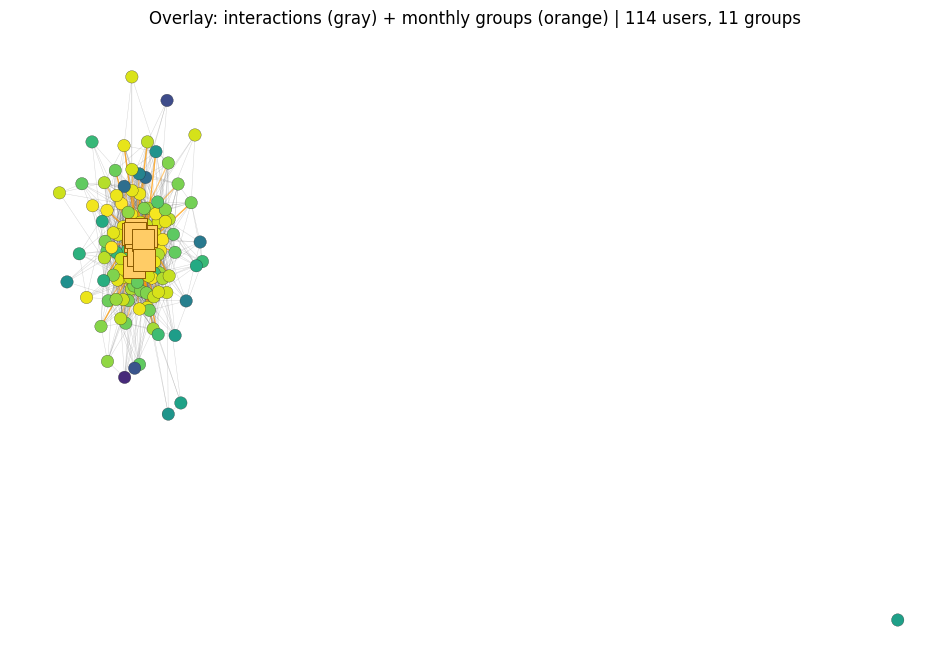

In [12]:
# ── Export + overlay visualization ─────────────────────────────────────────────

# For GEXF export, flatten non-serializable attrs (dicts/lists → strings).
def _export_copy(G):
    E = G.copy()
    for n in E.nodes:
        a = E.nodes[n].get("activity")
        if isinstance(a, dict):
            E.nodes[n]["activity"] = str(a)
    for u, v in E.edges:
        enc = E[u][v].get("encounters")
        if isinstance(enc, list):
            E[u][v]["encounters"] = str(enc)
    return E

# 1) Interaction-only graph
nx.write_gexf(_export_copy(G), "simulation.gexf")
print("Wrote: simulation.gexf")

# 2) Combined overlay (interactions + group membership) for Gephi
#
# Gephi usage:
#   - Partition > Nodes > "monthly_group" → colors each user by their assigned group
#   - Filter > Edges > "kind" = "membership" → show/hide membership spokes
#   - Filter > Nodes > "kind" = "group" → show/hide group hub nodes
#   - Node "is_seed" = true → highlight seed pair members

# Build a lookup: user -> group index (and whether they were a seed)
user_group = {}
user_is_seed = {}
for gi, members in enumerate(monthly_groups):
    for j, u in enumerate(members):
        user_group[u] = gi
        user_is_seed[u] = j < 2  # first two members are the seed pair

month = f"step_{N_STEPS}"
H = nx.MultiDiGraph()
for n, d in G.nodes(data=True):
    d2 = {**d, "kind": "user"}
    if isinstance(d2.get("activity"), dict):
        d2["activity"] = str(d2["activity"])
    d2["monthly_group"] = user_group.get(n, -1)   # -1 = unassigned
    d2["is_seed"]       = user_is_seed.get(n, False)
    H.add_node(n, **d2)
for u, v, d in G.edges(data=True):
    d2 = {**d, "kind": "interaction"}
    if isinstance(d2.get("encounters"), list):
        d2["encounters"] = str(d2["encounters"])
    H.add_edge(u, v, **d2)
for gi, members in enumerate(monthly_groups):
    gnode = f"group::{month}::{gi}"
    H.add_node(gnode, kind="group", monthly_group=gi, size=len(members))
    for u in members:
        H.add_edge(gnode, u, kind="membership")

nx.write_gexf(H, f"combined-overlay-{month}.gexf")
print(f"Wrote: combined-overlay-{month}.gexf")

# 3) Overlay plot
U_view = G.to_undirected(as_view=False)
pos_users = {n: pos[n] for n in U_view.nodes} if pos else nx.spring_layout(U_view, seed=SEED)
pos_all = dict(pos_users)
group_nodes = [n for n, d in H.nodes(data=True) if d.get("kind") == "group"]
for gn in group_nodes:
    members = [v for _, v in H.out_edges(gn) if v in pos_users]
    if members:
        pos_all[gn] = (sum(pos_users[m][0] for m in members) / len(members),
                       sum(pos_users[m][1] for m in members) / len(members))

plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos_all, node_size=80,
                       node_color=[max(G.nodes[n].get("activity", {}).values(), default=0) for n in G],
                       cmap=plt.cm.viridis, vmin=0, vmax=1, linewidths=0.2, edgecolors="#222")
nx.draw_networkx_edges(G, pos_all, arrows=False, width=0.3, alpha=0.12, edge_color="#444")
nx.draw_networkx_nodes(H, pos_all, nodelist=group_nodes, node_shape="s", node_size=240,
                       node_color="#ffcc66", linewidths=0.7, edgecolors="#8a5a00")
mem_edges = [(u, v) for u, v, d in H.edges(data=True) if d.get("kind") == "membership"]
nx.draw_networkx_edges(H, pos_all, edgelist=mem_edges, arrows=False, width=0.9, alpha=0.5, edge_color="#ff9900")
plt.title(f"Overlay: interactions (gray) + monthly groups (orange) | {G.number_of_nodes()} users, {len(group_nodes)} groups")
plt.axis("off"); plt.show()
